# Load mine locations

In [1]:
# import excel data from "data\Mining Dataset Capital IQ 11Nov2023.xlsx"
import pandas as pd
file_path = "data/Mining Dataset Capital IQ 11Nov2023.xlsx"
mine_sheet1 = pd.read_excel(file_path, sheet_name="Sheet1")
mine_sheet1.head()

,PROP_NAME,PROP_ID,PRIMARY_COMMODITY,DEV_STAGE,MINESEARCH_ID,LATITUDE,LONGITUDE,COORDINATE_ACCURACY,STATE_PROVINCE,COUNTRY_NAME,START_UP_YR,ACTUAL_CLOSURE_YR,EVENT_YR,Mine in Protected Area
0,101,64665,Coal,Operating,NaN,-28.73240,-49.24552,Exact,Santa Catarina,Brazil,NaN,NaN,NaN,NaN
1,1068,79522,Gold,Exploration,NaN,29.06976,-109.32652,Best Guess,Sonora,Mexico,NaN,NaN,NaN,NaN
2,11 RAU-Novaya,68289,Coal,Grassroots,NaN,48.51954,38.65827,Best Guess,Luhans'ka Oblast',Ukraine,NaN,NaN,NaN,NaN
3,113 North,87482,Nickel,Target Outline,NaN,48.73539,-77.12288,Exact,Quebec,Canada,NaN,NaN,NaN,NaN
4,1165L,63154,Coal,Advanced Exploration,NaN,-16.23000,34.00000,Exact,Tete,Mozambique,NaN,NaN,NaN,NaN


In [2]:
mine_sheet2 = pd.read_excel(file_path, sheet_name="Sheet2")
mine_sheet2.head()

,OBJECTID,PROP_NAME,PROP_ID,PRIMARY_COMMODITY,DEV_STAGE,ACTV_STATUS,SUBPROPERTY_,SUB_PROP_PARENT_ID,SUB_PROP_PARENT_NAME,COUNTRY_NAME,LATITUDE,LONGITUDE,DISTANCE_FROM,LOCATION_COMMENTS,OWNER_LIST,ROYALTY_HOLDER_LIST,Located in Protected Area
0,1,Three Hills,99057SP,Gold,Construction Planned,Active,Yes,32774.0,Hasbrouck,USA,38.061948,-117.261918,NaN,NaN,West Vault Mining Inc. (Owner) 100%,Unnamed Owner (NSR) 1.1%; West Vault Mining In...,NaN
1,2,Project 3 Merensky,99046SP,Platinum,Advanced Exploration,Active,Yes,32762.0,Maseve,South Africa,-25.370669,27.045836,NaN,NaN,Royal Bafokeng Platinum Limited (Owner) 100%,Liberty Mutual Insurance Company (Royalty) 1.5...,NaN
2,3,Project 1 Merensky,99044SP,Platinum,Construction Started,Active,Yes,32762.0,Maseve,South Africa,-25.409393,27.080390,NaN,NaN,Royal Bafokeng Platinum Limited (Owner) 100%,Liberty Mutual Insurance Company (Royalty) 1.5...,NaN
3,4,Mina Just and Magnetite Manto MI,98441SP,Copper,Feasibility,Active,Yes,32422.0,Marcona,Peru,-15.126684,-75.021134,NaN,NaN,Minsur S.A. (Venturer) 60%; Empresas Copec S.A...,NaN,NaN
4,5,Nonnenwerth,98354SP,Nickel,Advanced Exploration,Active,Yes,32396.0,Aurora,South Africa,-23.440000,28.955000,NaN,NaN,Sylvania Platinum Limited (Optionee) 75%; Impa...,NaN,NaN


# Load shapefile

In [3]:
countries = ['Cameroon']

# load shapefile data for Cameroon from data/liu-cameroon-roads/Cameroon.shp
import geopandas as gpd
shapefile_path = "data/liu-cameroon-roads/Cameroon.shp"
cameroon_roads = gpd.read_file(shapefile_path)
cameroon_roads.head()

,ID,Start_pt,End_pt,Rd_length,Surface,geometry
0,1,"(1103991.702615, 328198.947937)","(1103520.286835, 328787.695206)",762.730176,paved,"MULTILINESTRING ((1103991.703 328198.948, 1103..."
1,2,"(1103520.286835, 328787.695206)","(1103479.510506, 327812.637704)",980.028403,paved,"MULTILINESTRING ((1103520.287 328787.695, 1103..."
2,3,"(1094496.606460, 264352.420784)","(1094836.587317, 264478.208504)",364.363710,paved,"MULTILINESTRING ((1094496.606 264352.421, 1094..."
3,4,"(1102316.032584, 283330.554237)","(1101453.228606, 267250.567070)",23257.130654,unpaved,"MULTILINESTRING ((1102316.033 283330.554, 1102..."
4,5,"(1103057.420392, 327326.354672)","(1102985.552529, 327212.146541)",134.938827,paved,"LINESTRING (1103057.42 327326.355, 1102985.553..."


In [4]:
cameroon_roads.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 207451 entries, 0 to 207450
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype   
---  ------     --------------   -----   
 0   ID         207451 non-null  int32   
 1   Start_pt   207451 non-null  object  
 2   End_pt     207451 non-null  object  
 3   Rd_length  207451 non-null  float64 
 4   Surface    207451 non-null  object  
 5   geometry   207451 non-null  geometry
dtypes: float64(1), geometry(1), int32(1), object(3)
memory usage: 8.7+ MB


In [5]:
# count unique 'Surface' types in the shapefile data
surface_counts = cameroon_roads['Surface'].value_counts()
print(surface_counts)

Surface
unpaved    187241
paved       20210
Name: count, dtype: int64


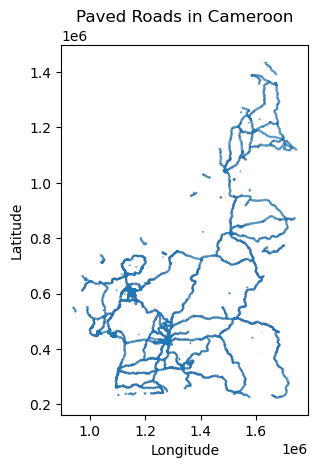

In [6]:
# plot road from shapefile
import matplotlib.pyplot as plt
# cameroon_roads.iloc[0:1000].plot()
# plot only 'Surface' == 'paved'
cameroon_roads[cameroon_roads['Surface'] == 'paved'].plot()
plt.title("Paved Roads in Cameroon")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

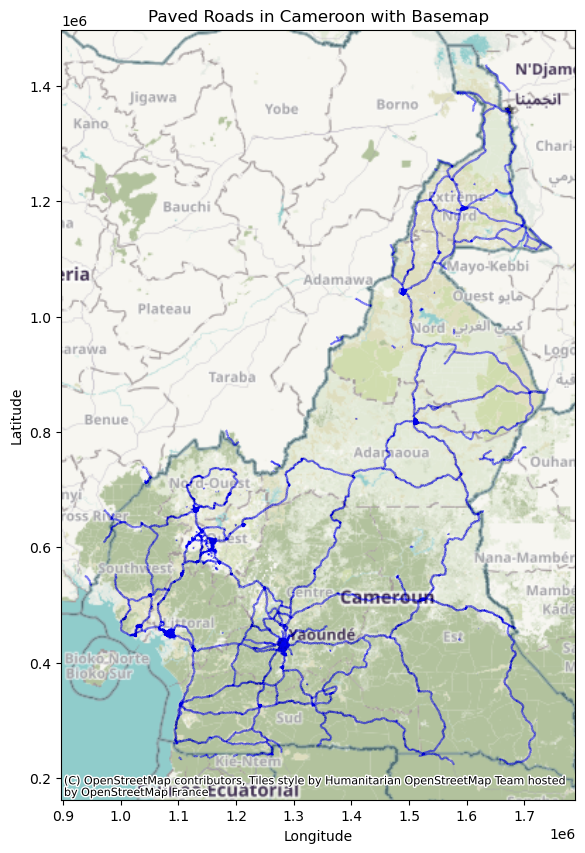

In [7]:
# plot paved roads on basemap
import contextily as ctx
ax = cameroon_roads[cameroon_roads['Surface'] == 'paved'].plot(figsize=(10, 10), alpha=0.5, edgecolor='b')
ctx.add_basemap(ax, crs=cameroon_roads.crs.to_string())
plt.title("Paved Roads in Cameroon with Basemap")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# Plot mine locations

In [8]:
countries = ['Cameroon']

# Filter the data for the specified countries
filtered_sheet1 = mine_sheet1[mine_sheet1['COUNTRY_NAME'].isin(countries)]
filtered_sheet2 = mine_sheet2[mine_sheet2['COUNTRY_NAME'].isin(countries)]
filtered_sheet1.head()

,PROP_NAME,PROP_ID,PRIMARY_COMMODITY,DEV_STAGE,MINESEARCH_ID,LATITUDE,LONGITUDE,COORDINATE_ACCURACY,STATE_PROVINCE,COUNTRY_NAME,START_UP_YR,ACTUAL_CLOSURE_YR,EVENT_YR,Mine in Protected Area
426,Akonolinga,51028,Iron Ore,Exploration,NaN,2.91626,12.16394,Exact,South,Cameroon,NaN,NaN,NaN,NaN
427,Akonolinga,52788,Heavy Mineral Sands,Prefeas/Scoping,NaN,3.78500,12.13800,Exact,Centre,Cameroon,NaN,NaN,NaN,NaN
2176,Bangou,65981,Bauxite,Grassroots,NaN,5.24000,10.37000,Approximate,West,Cameroon,NaN,NaN,NaN,NaN
2456,Batouri,36389,Gold,Exploration,118162.0,4.39820,14.40665,Exact,East,Cameroon,NaN,NaN,NaN,NaN
3002,Bibemi,50432,Gold,Reserves Development,125428.0,9.38893,14.00665,Exact,North,Cameroon,NaN,NaN,NaN,NaN


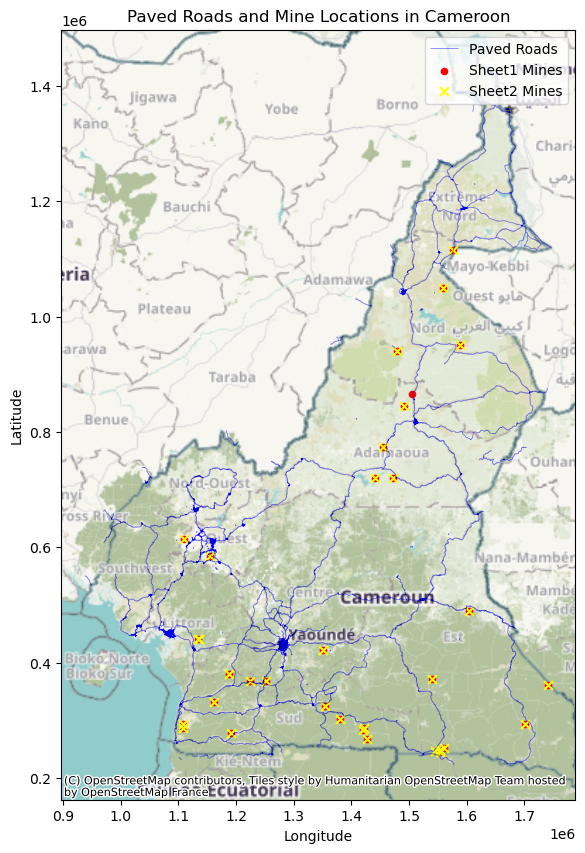

In [10]:
# plot paved roads and mine locations on a basemap
roads_3857 = cameroon_roads[cameroon_roads['Surface'] == 'paved'].to_crs(epsg=3857)

gdf_sheet1 = gpd.GeoDataFrame(filtered_sheet1, geometry=gpd.points_from_xy(filtered_sheet1['LONGITUDE'], filtered_sheet1['LATITUDE']), crs="EPSG:4326")
gdf_sheet2 = gpd.GeoDataFrame(filtered_sheet2, geometry=gpd.points_from_xy(filtered_sheet2['LONGITUDE'], filtered_sheet2['LATITUDE']), crs="EPSG:4326")

gdf1_3857 = gdf_sheet1.to_crs(epsg=3857)
gdf2_3857 = gdf_sheet2.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))
roads_3857.plot(ax=ax, color='blue', linewidth=0.5, alpha=0.6, label='Paved Roads')
gdf1_3857.plot(ax=ax, color='red', marker='o', markersize=20, label='Sheet1 Mines')
gdf2_3857.plot(ax=ax, color='yellow', marker='x', markersize=40, label='Sheet2 Mines')
ctx.add_basemap(ax, crs="EPSG:3857")
ax.set_title("Paved Roads and Mine Locations in Cameroon")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
plt.show()


In [11]:
len(gdf_sheet1), len(gdf_sheet2)

(31, 34)